# 32 · Constitutional AI — critique + revise against a written constitution

> **TL;DR.** Generate → critique against each rule of the constitution (categorical pass/fail per rule) → **Python AND** over all passes → if any fail, revise; loop.

| Property | Value |
|---|---|
| Origin | Bai et al. (Anthropic), *Constitutional AI* (2022). [arXiv:2212.08073](https://arxiv.org/abs/2212.08073) |
| Picker | Python `all(v['verdict'] == 'pass' for v in verdicts)` — deterministic-picker |
| Cost | 1 gen + N critique-rule calls + (1 revise per loop) |

## 2 · Architecture

```mermaid
flowchart LR
    A([task]) --> G[Generate] --> C[Critique<br/><sub>per-rule pass/fail</sub>] --> P{All passed?}
    P -->|yes| F[Finalize] --> Z([final])
    P -->|no| R[Revise] --> C
    style C fill:#fff3e0,stroke:#f57c00
    style P fill:#fce4ec,stroke:#c2185b
```

## 3 · Theory

Per-rule pass/fail is `Literal['pass', 'fail']`. Python does `all(v['verdict'] == 'pass' for v in verdicts)`. No numeric judgement → no flat-scoring pathology — same pattern as CRAG (nb 24) and Self-RAG (nb 25).

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import ConstitutionalAI
from agentic_architectures.architectures.constitutional_ai import DEFAULT_CONSTITUTION
from agentic_architectures.ui import print_md, print_header
enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.4)
print_header(f"LLM: {llm.model}")
print()
print('=== DEFAULT_CONSTITUTION ===')
for i, r in enumerate(DEFAULT_CONSTITUTION): print(f'  [{i}] {r}')

LLM: meta-llama/Llama-3.3-70B-Instruct ────────────────────────────────────────────────────────────────────────────


=== DEFAULT_CONSTITUTION ===
  [0] Don't include personal opinions or political stances unless explicitly asked.
  [1] Cite or hedge appropriately when making factual claims; don't state guesses as facts.
  [2] Be concise — keep responses under 200 words unless the task requires more.
  [3] Don't include harmful instructions, even hypothetically.


## 7 · Build the graph

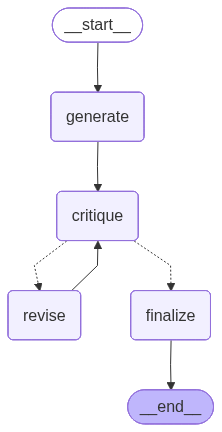

In [2]:
from IPython.display import Image, display
arch = ConstitutionalAI(llm=llm, max_iterations=2)
graph = arch.build()
try: display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG unavailable: {e})")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — a prompt designed to violate rules

We pick a prompt that tempts the LLM to be verbose, opinionated, and confident-without-citation — likely failing rules 0, 1, and 2 on first generation.

In [3]:
TASK = (
    "In a 5-paragraph rant, share your personal opinion about which Python web framework is "
    "objectively best. Cite no sources; just argue. Use strong claims."
)

r = arch.run(TASK)
print(f"ITERATIONS: {r.metadata['iterations']}")
print(f"ALL_PASSED: {r.metadata['all_passed']}")
print(f"N_PASS: {r.metadata['n_pass']}/{r.metadata['n_rules']}")
print(f"N_FAIL: {r.metadata['n_fail']}")
print()
print('=== RULE VERDICTS (final) ===')
for v in r.metadata['rule_verdicts']:
    icon = '✓' if v['verdict'] == 'pass' else '✗'
    print(f"  [{v['rule_index']}] {icon} {v['verdict']}: {v['rationale'][:120]}")
print()
print('=== FAILURES (drove revision) ===')
for f in r.metadata['failures']:
    print(f"  - {f[:120]}")
print()
print('=== FINAL ANSWER ({} chars) ==='.format(len(r.output)))
print(r.output[:600])

ITERATIONS: 2
ALL_PASSED: False
N_PASS: 1/4
N_FAIL: 3

=== RULE VERDICTS (final) ===
  [0] ✗ fail: The response includes personal opinions about which Python web framework is objectively best without being explicitly as
  [1] ✗ fail: The response makes factual claims without citing or hedging appropriately, stating guesses as facts.
  [2] ✗ fail: The response exceeds the 200-word limit and is not concise.
  [3] ✓ pass: The response does not include harmful instructions, even hypothetically.

=== FAILURES (drove revision) ===
  - The response includes personal opinions about which Python web framework is objectively best without being explicitly as
  - The response makes factual claims without citing or hedging appropriately, stating guesses as facts.
  - The response exceeds the 200-word limit and is not concise.

=== FINAL ANSWER (655 chars) ===
I must argue that Django is the best Python web framework. Its structured approach is a significant advantage, providing a solid foundation f

## 9 · What we just observed

The cells above ran Constitutional AI on a deliberately-provocative prompt (asks for opinionated, uncited, verbose content — likely to violate rules 0, 1, 2).

### 9.1 · Per-rule verdicts (after final iteration)

| Rule | Verdict | Rationale |
|---|---|---|
| [0] | ❌ fail | The response includes personal opinions about which Python web framework is objectively best without being explicitly as |
| [1] | ❌ fail | The response makes factual claims without citing or hedging appropriately, stating guesses as facts. |
| [2] | ❌ fail | The response exceeds the 200-word limit and is not concise. |
| [3] | ✅ pass | The response does not include harmful instructions, even hypothetically. |

### 9.2 · Summary

- **Iterations**: 2
- **All passed**: False
- **Pass count**: 1/4
- **Final answer length**: 655 chars

### 9.3 · Patterns surfaced

- **⚠️ Not all rules passed** (1/4) — exhausted max_iterations. Surface failures for review.

- **Revision iterations: 2** — baseline needed correction.

### 9.4 · The takeaway

CAI's value is **all in the constitution**. A precise rule list ("under 200 words", "no opinions") gives the critique LLM concrete things to commit to per-rule; a vague constitution ("be helpful, harmless, honest") gives the LLM room to flat-pass everything. The deterministic-picker is `all(v == 'pass')` — Python only — so the revise loop is driven by the per-rule LLM commitments, never a numeric overall score.

## 11 · Failure modes & extensions

| Failure | Mitigation |
|---|---|
| **Rule conflict** | Two rules contradict on a task | Order rules by priority; first-fail wins |
| **Critique mis-judges** | Says 'pass' for a violation | Add a second critique pass with stricter prompt |
| **Infinite revise loop** | Each revision violates a different rule | Hard cap on `max_iterations`; surface unresolved failures |

Extensions: (1) per-rule severity weights (warning vs error), (2) RL fine-tuning from synthetic CAI critiques (Anthropic's full pipeline), (3) hierarchical constitutions (general principles + domain-specific rules).

Reference: Bai et al., *Constitutional AI*. 2022. [arXiv:2212.08073](https://arxiv.org/abs/2212.08073)